# Primeras Pruebas para el modelo 

### Primer bloque | Carga, limpieza y codificación de los datos

En esta primera sección de nuestro código, la intención es preparar los datos para el clasidicador, a partir de los ~500 descriptores acústicos y los metadatos. Lo que haremos será:

* Lectura de nuestro corpus en formato CSV
* Imputaremos datos nulos o nan (en caso de que existan)
* Codificaremos el género (que será nuestro target) y artista, ya que es un dato categórico y con orden cardinal, lo cual puede afectar al entrenamiento.
* Realizaremos un split entre train y validation set en una proporción 80/20.
* Se estandarizarán las variables numéricas par su procesamiento. 

El corpus está compuesto de una gran cantidad de columnas que representan las features de nuestro dataset. 

## Codificación de etiquetas y variables categóricas

Sea $y \in \{1, ..., K\}$ el conjunto de etiquetas que representan los géneros musicales estudiados creado a partir de ```LabelEncoder```: 

$$
\text{Género} = \{ \text{Rock, Jazz, Pop, …} \} \;\;\to\;\; \{0,1,\dots,K-1\}
$$

$$
\text{Artista} = \{A_1, A_2,....,A_n, \text{Unknown}\} \;\;\to\;\; \{0,1, ..., A\}
$$

En la sección de Artista, estamos intentando garantizar que cuando aparezca un artista desconocido o "Unknown", este pertenezca al vocabulario. La codificación está preparada para ser un embedding, de tal modo que cada índice de artista $a$ se mapea a un vector denso $v(a) \in \mathbb{R}^d$. Agregar "Unknown" a nuestro encoder asegura que la matriz de embeddings tenga índice válido para todos los registros, tomando en cuenta posibles artistas presentes en el conjunto de test que no aparezcan en el train. Este mismo embedding de artistas evita one-hot con sparse alto, y permite representaciones que logren obtener información relevante de rasgos musicales asociados a artistas, que podrían representar bien a distintos géneros. 

Estandarizaremos también los datos de tal manera que para cada feature numérica $j$, con media $\mu_j$ y desviación $\sigma_j$ estimadas en train:

$$
x_{ij}^{(\text{std})} = \frac{x_{ij} - \mu_j}{\sigma_j}, \;\;\;\;\; \mu_j = \frac{1}{N_{\text{train}}} \sum_{i \in \text{train}} x_{ij}, \;\;\;\;\; \sigma_j^2 = \frac{1}{N_{\text{train}}} \sum_{i \in \text{train}} (x_{ij} - \mu_j)^2
$$

La homogeneización de nuestro conjunto siempre es buena idea, al tener tantos datos, las escalas comienzan a ser un problema si no se manejan. Así también apoyamos al optimizador (en este caso Adam). a no verse "capturados" por magnitudes dominantes. 



In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from collections import Counter
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

In [ ]:
print("Cargando y preparando datos...")
df = pd.read_csv('/home/cesar/Descargas/MIR-features-tarea01/fma_train_merged.csv')

# Manejar nulos
df.fillna(df.median(numeric_only=True), inplace=True)
df['artist.name'].fillna('Unknown', inplace=True)

# Codificar etiquetas
genre_encoder = LabelEncoder()

# Para artistas: añadimos "Unknown" manualmente
unique_artists = df['artist.name'].unique().tolist()
if "Unknown" not in unique_artists:
    unique_artists.append("Unknown")  # garantizamos que exista en el encoder

artist_encoder = LabelEncoder()
artist_encoder.fit(unique_artists)

df['genre_encoded'] = genre_encoder.fit_transform(df['track.genre1'])
df['artist_encoded'] = artist_encoder.transform(df['artist.name'])

print("Datos cargados. Primeras 5 filas:")
display(df[['artist.name', 'artist_encoded', 'track.genre1', 'genre_encoded']].head())


Cargando y preparando datos...
Datos cargados. Primeras 5 filas:


/tmp/ipykernel_5541/3611797678.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['artist.name'].fillna('Unknown', inplace=True)


,artist.name,artist_encoded,track.genre1,genre_encoded
0,AWOL,42,Hip-Hop,7
1,AWOL,42,Hip-Hop,7
2,AWOL,42,Hip-Hop,7
3,Kurt Vile,1301,Pop,12
4,AWOL,42,Hip-Hop,7


In [3]:
# Separar características numéricas, categóricas y la variable objetivo
numerical_cols = df.select_dtypes(include=np.number).columns.drop(['track_id', 'genre_encoded', 'artist_encoded'])
X_numerical = df[numerical_cols]
X_categorical = df['artist_encoded']
y = df['genre_encoded']

# Dividir en entrenamiento y validación (80/20)
# Usamos 'stratify=y' para asegurar que la proporción de géneros sea la misma en ambos conjuntos
X_num_train, X_num_val, X_cat_train, X_cat_val, y_train, y_val = train_test_split(
    X_numerical, X_categorical, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar características numéricas
# Es importante ajustar el scaler SOLO con los datos de entrenamiento para evitar fuga de datos
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)

print(f"Datos divididos: {len(X_num_train_scaled)} muestras de entrenamiento, {len(X_num_val_scaled)} de validación.")

Datos divididos: 9977 muestras de entrenamiento, 2495 de validación.


### Tratamiento de desbalance

El siguiente bloque lo que intenta es mitigar los problemas por desbalance de clases en el conjunto de entrenamiento. Recordemos que tenemos una alta carga sobre tres géneros principales:

* Rock con aprox. el 35\% del conjunto de train/val.
* Electrónica con aprox. el 20\% del conjunto train/val.
* Pop con aprox. el 10\% del conjunto train/val.
* El resto de los géneros con menos del 7\% del conjunto.
* Destacan Instrumental, Easy Lisening, Experimental y Soul-RnB con menos del 1\% cada una.

Este bloque calcula pesos inversos a la frecuencia, de ese modo, los pesos se pasan después a la función de pérdida, que en nuestro caso es ```CrossEntropyLoss``` para penalizar más los errores en las clases subrepresentadas. 

Si nuestro target codificado es $y \in \{0,1,...,K-1\}$, entonceS:

$$
n_k = \#\{i: y_i = k, i \in \text{train}\}. \;\;\;\;\; k = 0,1,...,K-1
$$

En este caso $n_k$ sería la frecuencia absoluta con que aparece cada género musical, i.e. el número exacto de canciones de un género dentro del conjunto. Los pesos los definimos con: ```class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)```. Esto se define como:

$$
\omega_k = \frac{1}{n_k}
$$ 

El problema con tener un conjunto de datos tan desbalanceado es que el modelo puede comenzar a ser demasiado especializado y solo predecir corectamente a los targets sobrerepresentados, tenienod por completo olvidado lo aprendido para las clases poco representadas. Si no podemos recurrir a más datos de cada género, aumentar e lpeso de error para las clases pequeñas es una buena primera solución. Con ello, el gradiente de una muestra poco representada tiene la misma importancia que la de una muestra común. En la prárctica, esto ayudaría a mejorar métricas como la macro-F1. 



In [4]:
# Contar cuántas muestras hay de cada clase en el conjunto de entrenamiento
class_counts = np.bincount(y_train)

# El peso es el inverso de la frecuencia
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)

print(f"Pesos calculados para las {len(class_counts)} clases.")

Pesos calculados para las 15 clases.


### DataLoader y Arquitectura del Modelo

En este tercer bloque lo que intentamos es organizar nuestros datos para pasarlos a la red y definir la arquitectura de la misma red. 

En la sección de ```class FMADataset(Dataset):``` lo que hacemos es definir un objeto iterable, en este caso, se trata d enuestro dataset de manera personalizada:

* ```__len__``` es el número de muestras.
* ```__getitem__``` devuelve un diccionario con entradas ```(numerical, categorical)```.
* ```train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)``` lo que hace es generar batches $B = \{i_1, ..., i_{64}\}$, mientras que el ```shuffle=TRUE``` asegura que el orden no introduzca sesgo en los gradientes. 
* ```self.embedding = nn.Embedding(num_artists, embedding_dim)``` es donde se aplica el embedding de artista para la red, evitando algo tipo one-hot y manejando mejor un vector denso. 
* ```x_combined = torch.cat([x_numerical, embedded_categorical], dim=1)``` concatena nuestras entradas, tanto lo numérico como lo categórico (representaod como embedding). Esto combina el artista, intentando capturar su estilo, con los descriptores acústicos, para intentar darle más contexto al modelo. 

Ahora bien, la arquitectura de la red está definida como: 

$$
\text{Dimensión:} (d+d_c) \;\to\; 256 \;\to\; 128 \;\to\; 64 \;\to\; K
$$

Tenemos como función de activación entre capas a LeakyReLU con un $\alpha = 0.01$k, y regularizamos con Dopout con probabilidad de 0.3. Al final, nuesto forward pass es:

$$
\vec{y} = f_{\theta}(z_i) \in \mathbb{R}^K
$$

Donde cada cpaa se representa como:

$$
h^{(l)} = \text{Dropout} \bigg(\phi(W^{(l)} h^{(l-1)} + b^{(l)})\bigg)
$$



In [5]:
class FMADataset(Dataset):
    """Dataset personalizado para manejar entradas numéricas y categóricas."""
    def __init__(self, numerical_features, categorical_features, labels):
        self.numerical = torch.tensor(numerical_features, dtype=torch.float32)
        self.categorical = torch.tensor(categorical_features, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'numerical': self.numerical[idx],
            'categorical': self.categorical[idx]
        }, self.labels[idx]

# Crear instancias del Dataset
train_dataset = FMADataset(X_num_train_scaled, X_cat_train.values, y_train.values)
val_dataset = FMADataset(X_num_val_scaled, X_cat_val.values, y_val.values)

# Crear los Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

class GenreClassifier(nn.Module):
    """Arquitectura MLP con una capa de Embedding para el artista."""
    def __init__(self, num_numerical_features, num_artists, embedding_dim, num_classes):
        super(GenreClassifier, self).__init__()
        self.embedding = nn.Embedding(num_artists, embedding_dim)
        
        input_size = num_numerical_features + embedding_dim
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_numerical, x_categorical):
        embedded_categorical = self.embedding(x_categorical)
        x_combined = torch.cat([x_numerical, embedded_categorical], dim=1)
        return self.layers(x_combined)

### Entrenamiento y Evaluación

En el siguiente bloque lo que haremos será definir la ejecución del ciclo de entrenamiento para nuestro ```DataLoader```, introduciendo regularización L1. Además, vamos a definir también nuestrras métricas de evaluación, como la pérdida, acurracy, y F1 (macro y weighted). 


El ciclo de entermiento es, para cada época:

* Tomamos cada uno de nuestros batches $B$ y obtenemos predicciones: $\hat{y} = f_{\theta}(x_i)$.
* Calculamos la pérdida con entropía cruzada pondera.
* Aplicamos regularización L1: $\ell \leftarrow \ell + \lambda \sum_{p \in \theta} |p|$.
* Comienza el Backpropagation y actualizamos los parámetros del optimizador. 

Creo que es importante aplicar regularización Lasso (L1) en este caso ya que suele ser bastante útil en escenarios dodne tenemos alta dimensionalidad. En nuestro caso, tenemos un dataset de aproximadamente 500 características, por lo que pienso que podríamos estar cayendo dentro de un área en el cual sería útil aplicar L1. 

Es decir, cuando el número de predictores es grande, pueden surgir diversos problemas. Uno de elos sería la redundancia y multicolinealidad, es muy probable que dentro de mis variables haya varias que estén fuertemente correlacioandas. Además, tenemos el caso latente del sobreajuste, al tener tantas variables, nuestro modelo podŕia comenzar a volverse propenso a memorizar ruido provocado por la alta correlación entre variables. La regularización L1 intenta resolver este tipo de problemas al introducir un término de penalización en la función objetivo de nuestro modelo. 

A diferencia de la regularización Ridge (L2), la norma L1 tiene la propiedad de que fuerza a que algunos coeficientes sean cero. Esto provoca que L1 sea una especie de filtro con el cual se seleccionan características integradas en el proceso de entrenamiento del modelo. 

La función CrossEntropy se vería de la siguiente manera al aplicar la regularización L1:

$$
\min_{\beta} \left[ - \frac{1}{N} \sum_{i=1}^{N} w_{c_i} \sum_{k=1}^{K} y_{i,k} \log(\hat{p}_{i,k}) \right] + \lambda \sum_{j=1}^{p} \left| \beta_j \right|
$$

El regulartizador $R_{L1} = \lambda \sum_{j=1}^{p} |\beta_1|$ es un término que penaliza la suma de los valores absolutos de los coeficientes del modleo, i.e. los $\beta_j$. El hiperparámetro $\lambda$ c0ntrola la intensidad de la penalización. 

In [ ]:
from sklearn.metrics import f1_score

def train_epoch(model, dataloader, loss_fn, optimizer, device, l1_lambda=0.0):
    model.train()
    total_loss = 0
    for data, labels in dataloader:
        numerical_data = data['numerical'].to(device)
        categorical_data = data['categorical'].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data)
        loss = loss_fn(outputs, labels)

        # L1 regularization
        if l1_lambda > 0:
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for data, labels in dataloader:
            numerical_data = data['numerical'].to(device)
            categorical_data = data['categorical'].to(device)
            labels = labels.to(device)
            
            outputs = model(numerical_data, categorical_data)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # Calcular métricas
    accuracy = 100 * correct / total
    # Macro F1: Trata a todas las clases por igual, sin importar su tamaño. ¡Muy importante para nosotros!
    macro_f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)
    # Weighted F1: Pondera el F1 de cada clase por su número de muestras.
    weighted_f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
            
    return total_loss / len(dataloader), accuracy, macro_f1, weighted_f1

### Configuración del Modleo y del Entrenamiento 


Aquí, lo primero que hacemos es revisar que podamos acceder a la GPU de mi laptop. Si no está disponible, nos pasamos a CPU. 

Después sigue instanciar el número correcto de features, artistas y géneros con el ```GenreClassifier```. Modificamos un poco la pérdida para darle más opciones para mitigar el desbalance. Introducimos Smoothing, o Focal Loss en caso de no querer usar la primera. Además, modificamos Adam para utilizar L2, e introducimos Scheduler con ```ReduceLROnPlateau``` para ajustar de manera dinámica la tasa de aprendizaje según la validación de nuestro modelo. 

El label smoothing cambia el tipo de salida. Normalmente un clasificador tiene un target one-hot del tipo $y = (1,0,0,0,0,0,....,0)$. Esto obliga al modelo a asignar el 100\% de probabilidad a la clase correcta, penalizando en sobremanera cualquier desviación. Esto provoca que el modelo tienda a la sobreconfianza. Lo que intentamos haer es pasar de algo rígido como:

$$
y_k = \begin{cases} 1 & \text{si } k=y \\ 0 & \text{si } k \neq y \end{cases}
$$

A algo más plástico como:

$$
\tilde{y}_k = \begin{cases} 1-\varepsilon & \text{si } k = y \\ \frac{\varepsilon}{K-1} & \text{si } k \neq y \end{cases}
$$

Esto es otra manera de intentar mitigar el overfititng. Las salidas de nuestra Softmax serán más suavez y mejor calibradas. Además, es un impulso para generalizar mejor, se supone que ayuda a datasets con complejidad en las etiquetas. 

Ahora bien, se preferimos usar Focal Loss, podemos activar la pérdida con FL. Para dataset desbalanceados, la clase sobrerepresentada suele ser fácilmente clasificada. El modelo se esfuerza más en aprender de ese conjunto, pero olvida las menos representadas. FL intenta que la pérdiad se enfoque en los ejemplos más raros o difíciles de aprender. 

$$
L_{\text{Focal}} = - \sum_{i=1}^{N} \alpha_{y_i} (1 - p_{y_i})^{\gamma} \log(p_{y_i})
$$

En este caso $p_{y_i}$ es la probabilidad asignada a la clase correcta. $(1 - p_{y_i})^\gamma$ pondera, si el modelo ya está seguro entonces $p = 1$ y el factor se aproximaa a 0, si el modelo falla, entonces el factor se aproxima a 1 y la pérdida es alta. $\gamma$ controla cuánto enfoque darle a los ejemplos difíciles, típicamente se usa $\gamma = 2$. De esa manera, los ejemplos fáciles pierden importancia enseguida, mientras que los complicados u outliers pesan mśa en el gradiente. 




In [ ]:
# Configuración del dispositivo (GPU si está disponible, si no, CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Mover los pesos al dispositivo correcto
class_weights = class_weights.to(device)

# Instanciar el modelo
model = GenreClassifier(
    num_numerical_features=len(numerical_cols),
    num_artists=len(artist_encoder.classes_),
    embedding_dim=32,
    num_classes=len(genre_encoder.classes_)
).to(device)
class FocalLoss(nn.Module):
    """
    Focal Loss multiclase (estilo RetinaNet).
    - alpha: tensor [C] (pesos por clase). Se normaliza a media=1 para no cambiar la escala de la CE.
    - gamma: tipicamente 1.5–2.0
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction

        if alpha is not None:
            alpha = torch.as_tensor(alpha, dtype=torch.float32)
            # Normalizamos para que la media sea 1 (evita escalar la pérdida global)
            alpha = alpha / alpha.mean()
            # Registrar como buffer => viaja con .to(device), se guarda en state_dict, etc.
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        # inputs: [N, C] logits; targets: [N] int64
        # CE por muestra (sin reducción)
        ce = F.cross_entropy(inputs, targets, reduction='none')

        # p_t = exp(-CE)    (equivale a probs de la clase verdadera)
        pt = torch.exp(-ce)

        # Focal: (1 - p_t)^gamma * CE
        loss = (1.0 - pt) ** self.gamma * ce

        # Ponderación por clase (alpha) si se proporcionó
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)   # [N]
            loss = at * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss  # [N]

# Función de pérdida con smoothing (mejor calibración, menos sobre-confianza)
loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

# Usar Focal Loss en lugar de CrossEntropy con smoothing
# loss_fn = FocalLoss(alpha=class_weights, gamma=2.0, reduction='mean')

optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay= 2e-4)#1e-4)  # L2

# Scheduler: reduce el LR a la mitad si la val_loss no mejora en 5 épocas
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',      # queremos minimizar la val_loss
    factor=0.5,      # lr <- lr * 0.5 cuando activa
    patience=5,      # nº de épocas sin mejora antes de reducir
    threshold=1e-3,  # mejora mínima para considerarse "mejora"
    cooldown=0,      # épocas de “descanso” tras reducir LR
    min_lr=1e-6      # LR mínimo
)

def get_lr(optim_):
    return optim_.param_groups[0]['lr']

print("Modelo, función de pérdida y optimizador configurados.")

Usando dispositivo: cuda
Modelo, función de pérdida y optimizador configurados.


### Ejecución del modelo 

Este bloque implementa nuestro ciclo de entrenamiento:

* Primero ejecuta ```train_epoch``` y ```evaluate``` en cada época.
* Usa el scheduler para ajustar de manera dinámica el learning rate según los cambios en la pérdiad de validación.
* Guarda métricas en un diccionario llamado ```history``` que nos ayudará a los plots de validación del modleo.
* Imprime resultados de cada época. 

In [ ]:
NUM_EPOCHS = 50

# Listas para guardar el historial
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_macro_f1': [],
    'val_weighted_f1': []
}
    
print("\n Iniciando Entrenamiento ")
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device, l1_lambda=1e-5)
    val_loss, val_accuracy, val_macro_f1, val_weighted_f1 = evaluate(model, val_loader, loss_fn, device)

    # Actualizar el scheduler con la métrica que queremos bajar (val_loss)
    scheduler.step(val_loss)

    # Guardar historial (igual que ya lo hacías)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_macro_f1'].append(val_macro_f1)
    history['val_weighted_f1'].append(val_weighted_f1)

    # (Opcional) mostrar LR actual para diagnóstico
    current_lr = get_lr(optimizer)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}% | "
          f"Macro F1: {val_macro_f1:.4f} | "
          f"Weighted F1: {val_weighted_f1:.4f} | "
          f"LR: {current_lr:.2e}")

print("\nEntrenamiento Finalizado")


--- Iniciando Entrenamiento ---
Epoch 01/50 | Train Loss: 4.1496 | Val Loss: 3.1574 | Val Acc: 24.05% | Macro F1: 0.1672 | Weighted F1: 0.2730 | LR: 5.00e-04
Epoch 02/50 | Train Loss: 3.7750 | Val Loss: 2.9658 | Val Acc: 31.78% | Macro F1: 0.2572 | Weighted F1: 0.3546 | LR: 5.00e-04
Epoch 03/50 | Train Loss: 3.5315 | Val Loss: 2.8373 | Val Acc: 32.55% | Macro F1: 0.2695 | Weighted F1: 0.3820 | LR: 5.00e-04
Epoch 04/50 | Train Loss: 3.3162 | Val Loss: 2.7377 | Val Acc: 38.08% | Macro F1: 0.3109 | Weighted F1: 0.4218 | LR: 5.00e-04
Epoch 05/50 | Train Loss: 3.1724 | Val Loss: 2.6795 | Val Acc: 38.12% | Macro F1: 0.3221 | Weighted F1: 0.4275 | LR: 5.00e-04
Epoch 06/50 | Train Loss: 2.9947 | Val Loss: 2.6097 | Val Acc: 39.52% | Macro F1: 0.3418 | Weighted F1: 0.4456 | LR: 5.00e-04
Epoch 07/50 | Train Loss: 2.8861 | Val Loss: 2.5403 | Val Acc: 43.45% | Macro F1: 0.3774 | Weighted F1: 0.4903 | LR: 5.00e-04
Epoch 08/50 | Train Loss: 2.7906 | Val Loss: 2.5017 | Val Acc: 47.82% | Macro F1: 0.4

### Plots y validación

* Aquí obtenemos las predicciones y probabilidades finales del modelo. 
* Después, visualizamos la evolución del entrenamiento.
* Analizamos el rendimiento final con matriz de confusión (errores por clase) y Curvas ROC (rendimiento binario one-vs-rest).

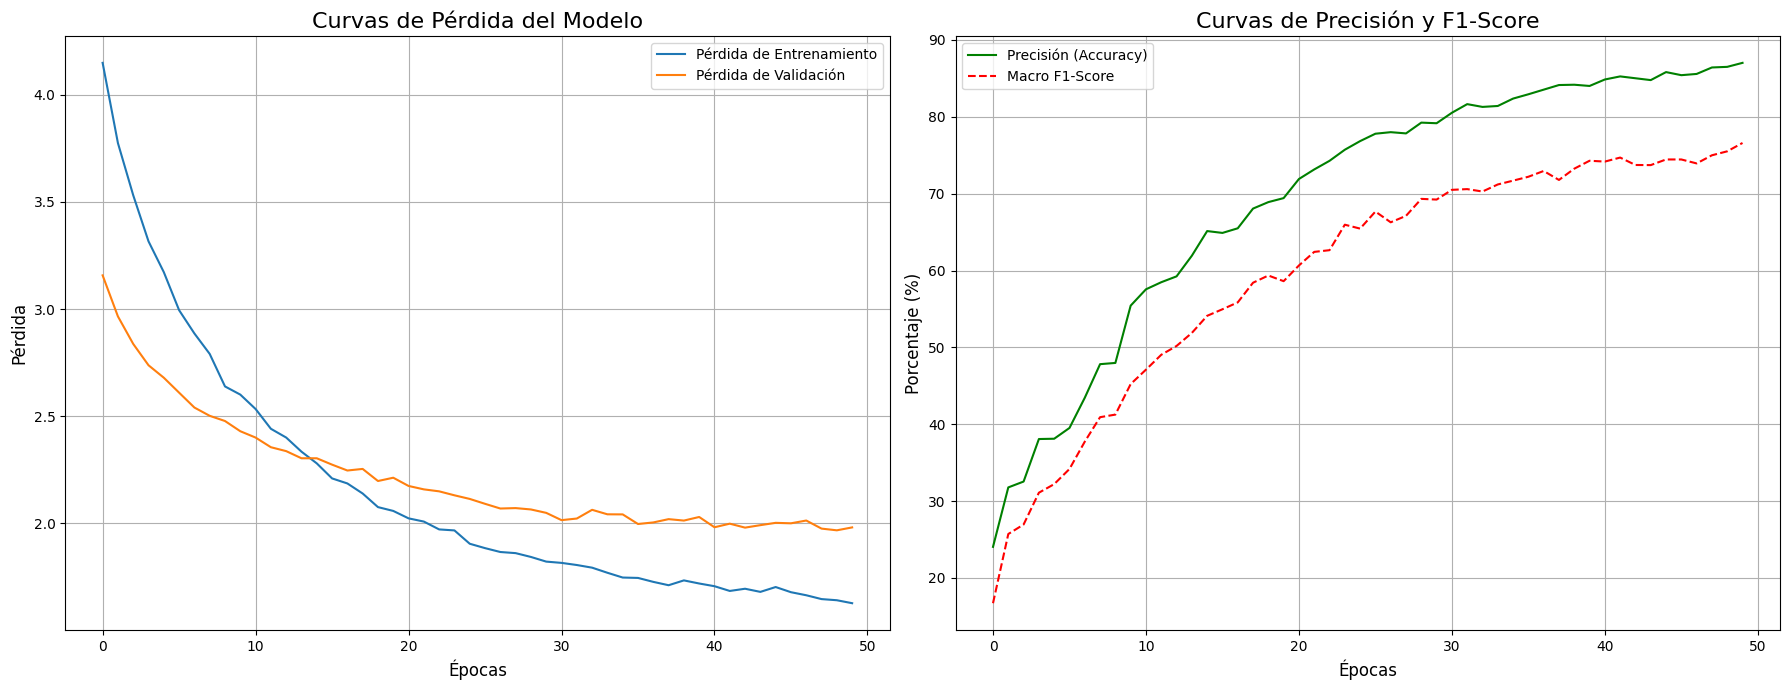

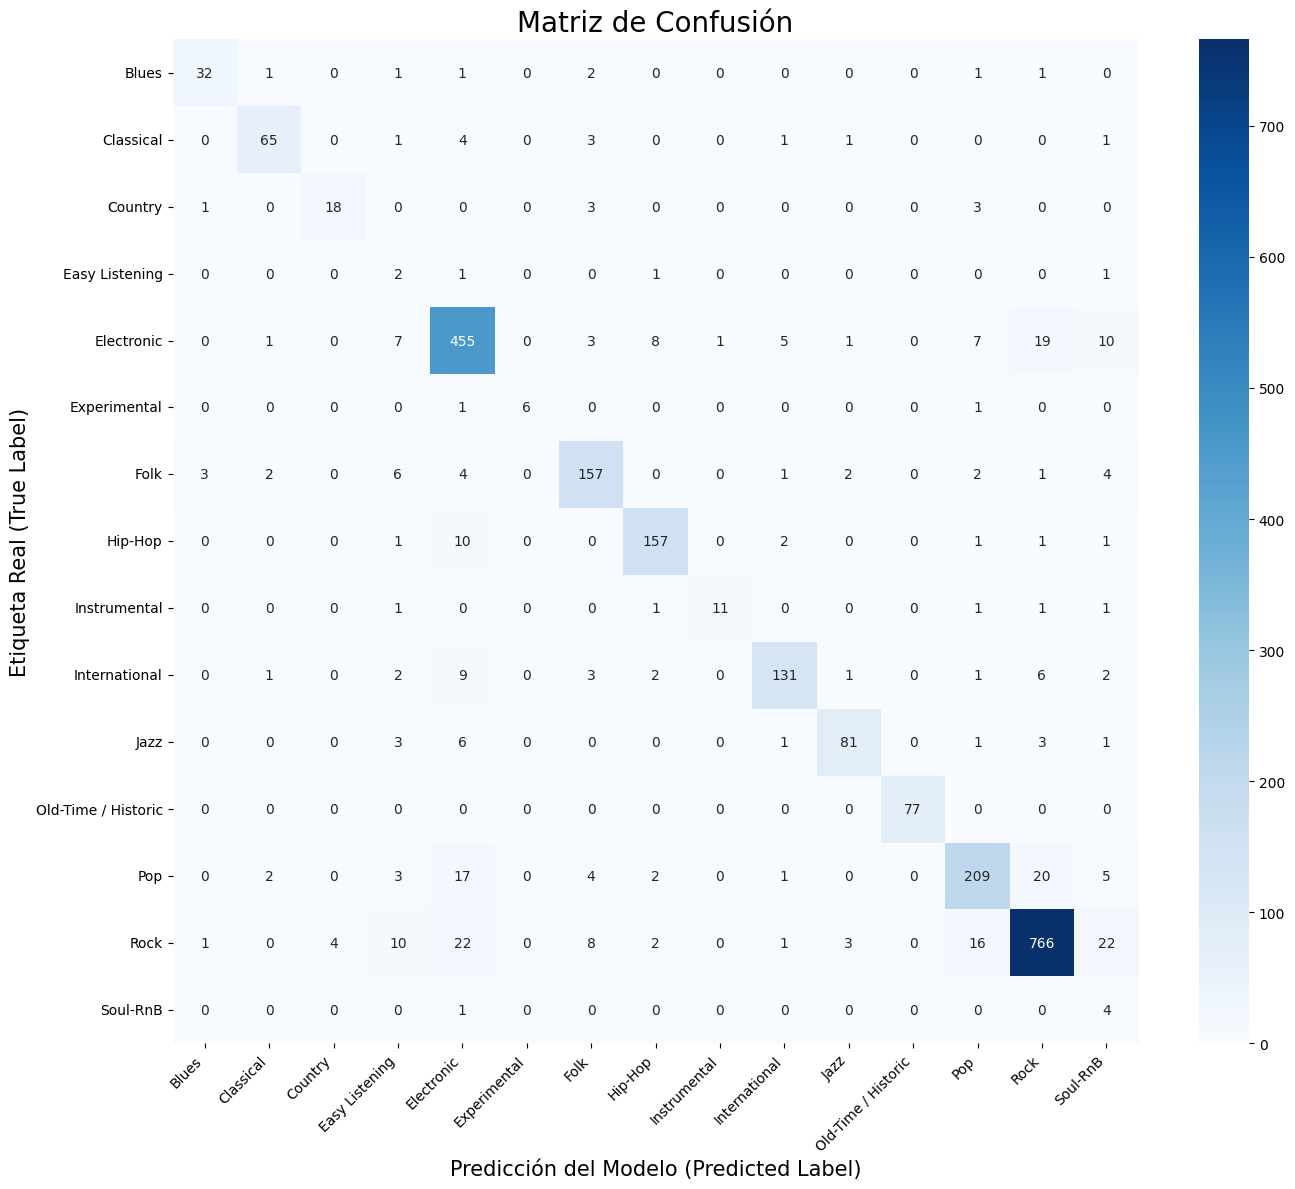

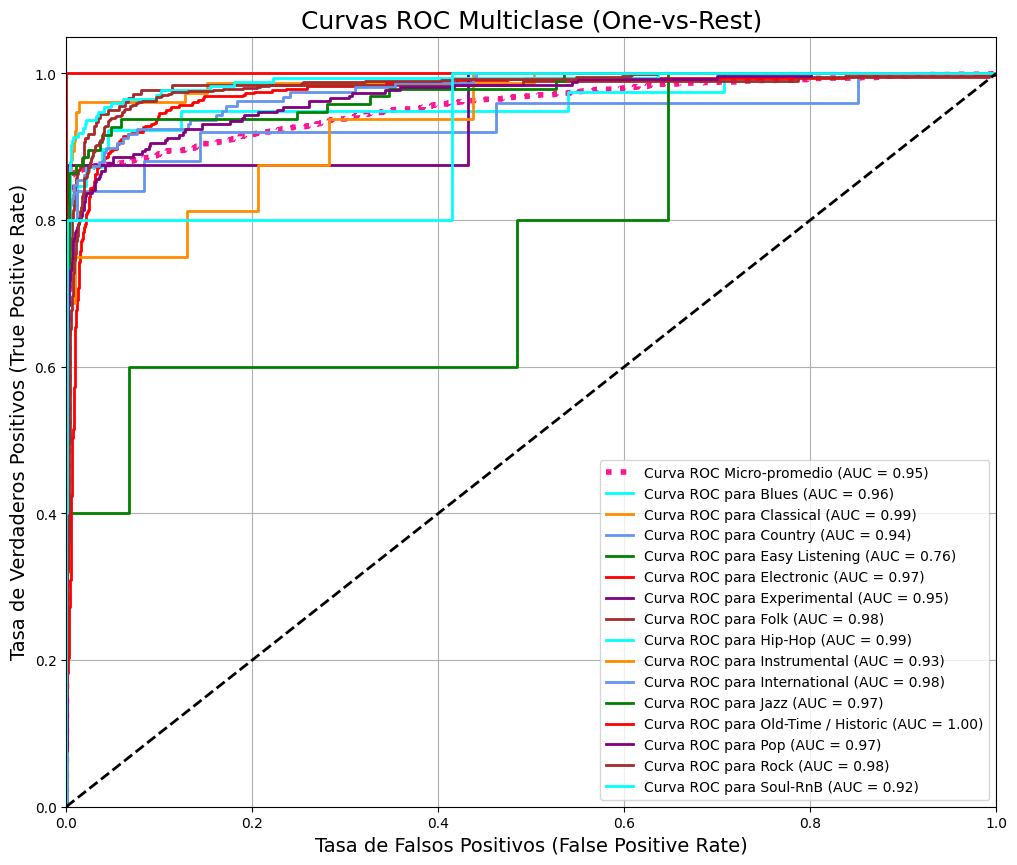

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import seaborn as sns

# Obtener las predicciones y puntuaciones finales del modelo entrenado
# Definimos una función final que devuelve todo lo necesario para los gráficos
def get_final_outputs(model, dataloader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    all_scores = []
    with torch.no_grad():
        for data, labels in dataloader:
            numerical_data = data['numerical'].to(device)
            categorical_data = data['categorical'].to(device)
            outputs = model(numerical_data, categorical_data)
            
            # Obtener puntuaciones de probabilidad con softmax
            scores = torch.nn.functional.softmax(outputs, dim=1)
            # Obtener la clase predicha
            _, predicted = torch.max(outputs.data, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_scores.extend(scores.cpu().numpy())
            
    return np.array(all_labels), np.array(all_predictions), np.array(all_scores)

final_labels, final_predictions, final_scores = get_final_outputs(model, val_loader, device)


# Graficar Curvas de Pérdida, Precisión y F1-Score 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
# Gráfico de Pérdida (Loss)
ax1.plot(history['train_loss'], label='Pérdida de Entrenamiento')
ax1.plot(history['val_loss'], label='Pérdida de Validación')
ax1.set_title('Curvas de Pérdida del Modelo', fontsize=16)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Pérdida', fontsize=12)
ax1.legend()
ax1.grid(True)
# Gráfico de Precisión (Accuracy) y F1-Score
ax2.plot(history['val_accuracy'], label='Precisión (Accuracy)', color='green')
ax2.plot(np.array(history['val_macro_f1']) * 100, label='Macro F1-Score', color='red', linestyle='--')
ax2.set_title('Curvas de Precisión y F1-Score', fontsize=16)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Porcentaje (%)', fontsize=12)
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()


# Graficar Matriz de Confusión
cm = confusion_matrix(final_labels, final_predictions)
genre_names = genre_encoder.classes_
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genre_names, yticklabels=genre_names)
plt.title('Matriz de Confusión', fontsize=20)
plt.ylabel('Etiqueta Real (True Label)', fontsize=15)
plt.xlabel('Predicción del Modelo (Predicted Label)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#  Graficar Curva ROC Multiclase
y_true_binarized = label_binarize(final_labels, classes=range(len(genre_encoder.classes_)))
n_classes = y_true_binarized.shape[1]
fpr, tpr, roc_auc = dict(), dict(), dict()

# Calcular la curva ROC para cada clase
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], final_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular la curva ROC micro-promediada
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), final_scores.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Visualización
plt.figure(figsize=(12, 10))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Curva ROC Micro-promedio (AUC = {roc_auc["micro"]:0.2f})',
         color='deeppink', linestyle=':', linewidth=4)

colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Curva ROC para {genre_encoder.classes_[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (False Positive Rate)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (True Positive Rate)', fontsize=14)
plt.title('Curvas ROC Multiclase (One-vs-Rest)', fontsize=18)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Prueba en el Test 
Tomamos el corpus de test para obtener prediciones sobre canciones nunca antes vistas por el modelo. 

In [ ]:
# Cargar dataset de test
df_test = pd.read_csv("/home/cesar/Descargas/MIR-features-tarea01/fma_test_merged.csv")

# Imputación de nulos (igual que en train)
df_test.fillna(df_test.median(numeric_only=True), inplace=True)
df_test['artist.name'].fillna('Unknown', inplace=True)

# Manejo de artistas desconocidos
known_artists = set(artist_encoder.classes_)
df_test['artist.name'] = df_test['artist.name'].apply(
    lambda x: x if x in known_artists else "Unknown"
)

# Codificar artistas con el mismo encoder entrenado
df_test['artist_encoded'] = artist_encoder.transform(df_test['artist.name'])

# Codificar géneros si tienes etiquetas verdaderas en test
if 'track.genre1' in df_test.columns:
    df_test['genre_encoded'] = genre_encoder.transform(df_test['track.genre1'])
    y_test = df_test['genre_encoded'].values
else:
    y_test = None

# Escalar las características numéricas con el scaler de train
X_num_test_scaled = scaler.transform(df_test[numerical_cols])
X_cat_test = df_test['artist_encoded'].values



/tmp/ipykernel_5541/3579284646.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['artist.name'].fillna('Unknown', inplace=True)


In [12]:
test_dataset = FMADataset(
    X_num_test_scaled, 
    X_cat_test, 
    y_test if y_test is not None else np.zeros(len(X_cat_test))
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def predict(model, dataloader, device):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for data, _ in dataloader:  # labels pueden no estar en test
            num = data['numerical'].to(device)
            cat = data['categorical'].to(device)
            outputs = model(num, cat)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)

# Obtener predicciones
y_pred = predict(model, test_loader, device)

# Decodificar a etiquetas de género
pred_genres = genre_encoder.inverse_transform(y_pred)

# Guardar en el DataFrame
df_test['predicted_genre'] = pred_genres

print(df_test[['track_id', 'artist.name', 'predicted_genre']].head())

print(df_test[['track_id', 'artist.name', 'predicted_genre']])


   track_id artist.name predicted_genre
0       194    Ed Askew            Folk
1       196    Ed Askew            Folk
2       198    Ed Askew            Folk
3       206    Ed Askew            Folk
4       207    Ed Askew            Folk
     track_id artist.name predicted_genre
0         194    Ed Askew            Folk
1         196    Ed Askew            Folk
2         198    Ed Askew            Folk
3         206    Ed Askew            Folk
4         207    Ed Askew            Folk
..        ...         ...             ...
652    123945   Dazie Mae           Blues
653    123963   Dazie Mae           Blues
654    124137      Mekons   International
655    124185    Bloodgod            Rock
656    124819   Leisure-B      Electronic

[657 rows x 3 columns]


### Guardamos los resultados

In [14]:
# Guardar predicciones en CSV
if 'track.genre1' in df_test.columns:
    # Si el test tiene etiquetas verdaderas
    df_test[['track_id', 'track.genre1', 'predicted_genre']].to_csv(
        "test_predictions.csv", index=False
    )
else:
    # Si el test no tiene etiquetas
    df_test[['track_id', 'predicted_genre']].to_csv(
        "test_predictions_01.csv", index=False
    )

print("Predicciones guardadas en test_predictions_01.csv")

Predicciones guardadas en test_predictions_01.csv
